# Route & molecule synthesizability score analysis

Analyzes `data/processed/analysis/routes_aggregated.csv` -- the merge of
`data/routes/routes.csv`, `scripts/chem_mol_scoring/molecule_scores.py`
(SA/NP/QED/descriptor/SCScore/RAscore), `scripts/chem_route_scoring/route_scores.py`
(route structural metrics + HAC-weighted stock availability), and an
LLM-judge run from `scripts/llm_scoring/llm_scoring.py`. See
`docs/CHEM_SCORING.md` for how each column was produced and how to
regenerate this file.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from rdkit import Chem
from rdkit.Chem import Draw
from autorank import autorank, create_report, plot_stats

import sys; sys.path.insert(0, "../scripts/llm_scoring")
from route_parsing import parse_route_row, render_route_for_llm

sns.set_theme(style="whitegrid")
PALETTE = sns.color_palette("colorblind")
pd.set_option("display.max_colwidth", 60)

In [2]:
df = pd.read_csv("../data/processed/analysis/routes_aggregated.csv")
print(f"{len(df)} routes x {len(df.columns)} columns")

column_groups = {
    "base":            ["SMILES", "score", "resolved", "pool", "search_duration", "resolved_depth"],
    "molecule scores": ["sa_score", "np_score", "qed", "scscore", "rascore"],
    "route scores":    ["route_resolved", "route_n_steps", "route_max_depth", "route_n_building_blocks",
                         "route_n_unresolved_leaves", "route_convergence", "route_hac_weighted_score"],
    "llm scores":      ["llm_mode", "llm_score", "llm_category", "llm_confidence"],
}
for group, cols in column_groups.items():
    print(f"\n-- {group} --")
    print(df[cols].isna().sum().rename("n_null"))

4000 routes x 143 columns

-- base --
SMILES               0
score                0
resolved             0
pool                 0
search_duration      0
resolved_depth     565
Name: n_null, dtype: int64

-- molecule scores --
sa_score    0
np_score    0
qed         0
scscore     0
rascore     0
Name: n_null, dtype: int64

-- route scores --
route_resolved                 0
route_n_steps                  0
route_max_depth                0
route_n_building_blocks        0
route_n_unresolved_leaves      0
route_convergence            565
route_hac_weighted_score     565
Name: n_null, dtype: int64

-- llm scores --
llm_mode          0
llm_score         0
llm_category      0
llm_confidence    0
Name: n_null, dtype: int64


## Helpers

Shared by several sections below.

In [3]:
def hardness_percentile(series: pd.Series, high_is_hard: bool) -> pd.Series:
    """Percentile rank (0-100) on a common "hardness" scale: 100 = hardest.

    Puts differently-scaled/oriented scores (sa_score 1-10 low=easy, scscore
    1-5 high=hard, rascore/llm_score high=easy, ...) onto the same direction
    and range so they can be compared or fed into the same statistical test.
    `high_is_hard=True` for scores where a high raw value already means
    harder (sa_score, scscore); False where a high raw value means easier
    (llm_score, rascore, route_hac_weighted_score).
    """
    return series.rank(pct=True, ascending=high_is_hard) * 100


def mol_grid(smiles, legends, mols_per_row=4, sub_img_size=(250, 250)):
    """RDKit grid image for a list of SMILES, skipping unparseable ones."""
    mols, kept_legends = [], []
    for smi, legend in zip(smiles, legends):
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            mols.append(mol)
            kept_legends.append(legend)
    return Draw.MolsToGridImage(mols, molsPerRow=mols_per_row, subImgSize=sub_img_size, legends=kept_legends)

## 1. Score distributions

Each score's own marginal distribution, before comparing them to one
another. Worth checking for ceiling/floor saturation (a score that piles up
at one extreme isn't discriminating much within this molecule class) and for
multimodality (a score that separates the data into distinct clusters).

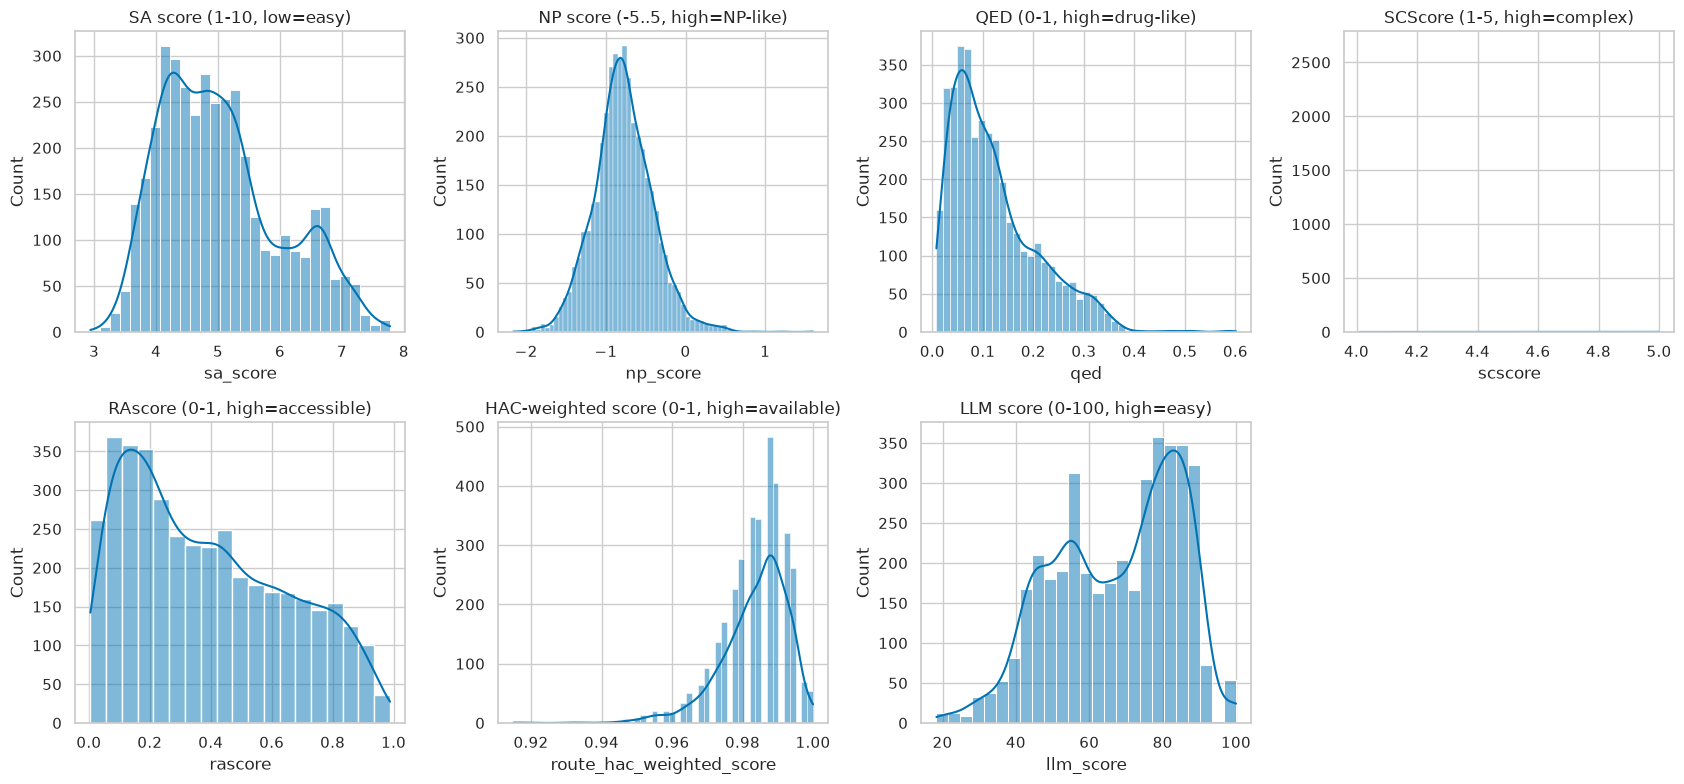

In [4]:
dist_scores = [
    ("sa_score", "SA score (1-10, low=easy)"),
    ("np_score", "NP score (-5..5, high=NP-like)"),
    ("qed", "QED (0-1, high=drug-like)"),
    ("scscore", "SCScore (1-5, high=complex)"),
    ("rascore", "RAscore (0-1, high=accessible)"),
    ("route_hac_weighted_score", "HAC-weighted score (0-1, high=available)"),
    ("llm_score", "LLM score (0-100, high=easy)"),
]
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, (col, title) in zip(axes.flat, dist_scores):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color=PALETTE[0])
    ax.set_title(title)
    ax.set_xlabel(col)
for ax in axes.flat[len(dist_scores):]:
    ax.set_visible(False)
plt.tight_layout()

## 2. Cheap-vs-expensive agreement

Does the (free, local, seconds-to-compute) `sa_score`/`scscore`/`rascore`/`route_hac_weighted_score`
track the (API-cost, minutes-to-hours) `llm_score`? If they agree well, the
cheap scores could pre-filter or triage which routes are worth spending
LLM-judge budget on. Note the expected SIGN: `sa_score`/`scscore` are
LOW=easier while `llm_score`/`rascore` are HIGH=easier, so real agreement
shows up as a *negative* correlation for the first two and *positive* for
`rascore`/`route_hac_weighted_score`.

In [5]:
cheap_scores = ["sa_score", "np_score", "qed", "scscore", "rascore", "route_hac_weighted_score", "route_n_steps"]
rows = []
for col in cheap_scores:
    mask = df[col].notna() & df["llm_score"].notna()
    r, p = pearsonr(df.loc[mask, col], df.loc[mask, "llm_score"])
    rows.append({"score": col, "r": r, "p": p, "n": int(mask.sum())})
corr_table = pd.DataFrame(rows).set_index("score")
corr_table

,r,p,n
score,,,
sa_score,-0.408187,1.813108e-160,4000
np_score,-0.330808,9.190765e-103,4000
qed,0.050805,1.307795e-03,4000
scscore,-0.058686,2.042949e-04,4000
rascore,0.275536,1.297143e-70,4000
route_hac_weighted_score,0.539055,3.006414e-258,3435
route_n_steps,-0.098788,3.817849e-10,4000


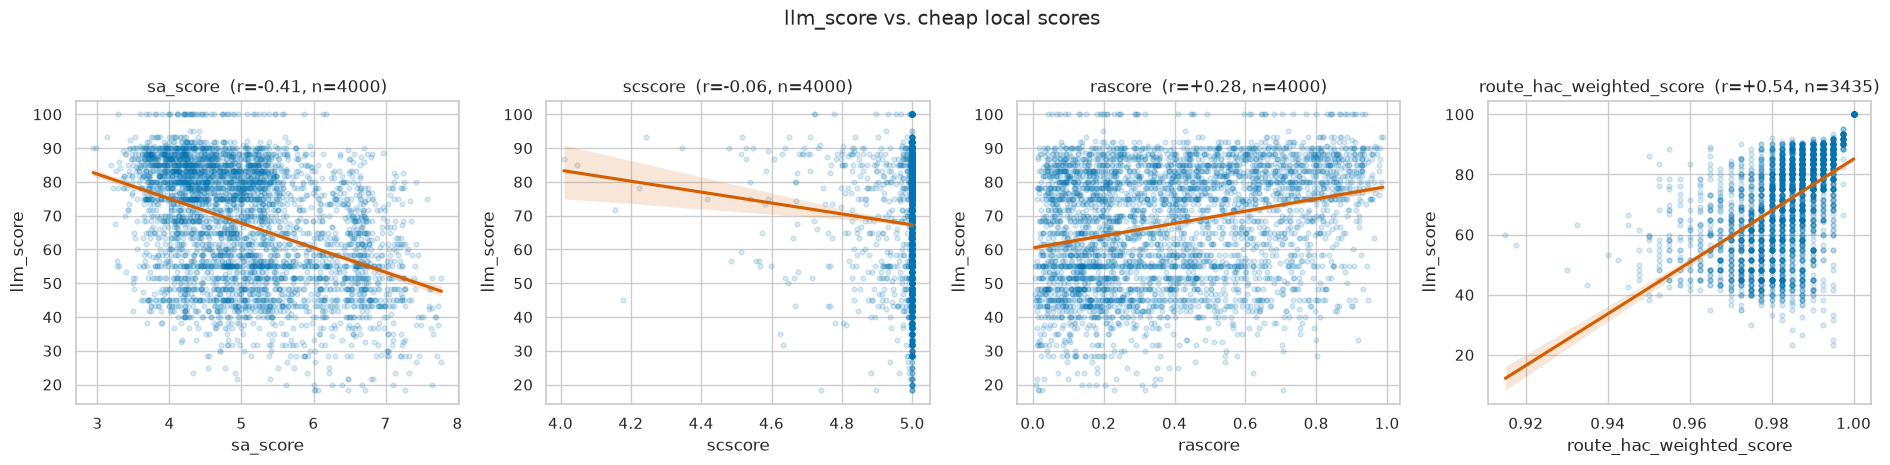

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
for ax, col in zip(axes, ["sa_score", "scscore", "rascore", "route_hac_weighted_score"]):
    mask = df[col].notna() & df["llm_score"].notna()
    sns.regplot(data=df.loc[mask], x=col, y="llm_score", ax=ax, scatter_kws={"alpha": 0.15, "s": 12},
               line_kws={"color": PALETTE[3]}, color=PALETTE[0])
    r, p = corr_table.loc[col, ["r", "p"]]
    ax.set_title(f"{col}  (r={r:+.2f}, n={int(corr_table.loc[col, 'n'])})")
fig.suptitle("llm_score vs. cheap local scores", y=1.03)
plt.tight_layout()

## 3. Resolved vs. unresolved

Is AiZynthFinder failing (`resolved == False`) because these targets are
genuinely more complex/less accessible by the cheap scores too, or for
reasons those scores don't see (e.g. missing stock, not molecular complexity)?

In [7]:
summary_cols = ["sa_score", "scscore", "rascore", "qed", "route_hac_weighted_score"]
df.groupby("resolved")[summary_cols].agg(["mean", "median", "std"]).T

resolved                            False     True 
sa_score                 mean    5.720138  4.926550
                         median  5.668328  4.775887
                         std     0.967976  0.915907
scscore                  mean    4.988489  4.986155
                         median  5.000000  5.000000
                         std     0.053416  0.063565
rascore                  mean    0.285694  0.404720
                         median  0.219502  0.369592
                         std     0.222364  0.261995
qed                      mean    0.110296  0.123935
                         median  0.084351  0.103687
                         std     0.081659  0.086095
route_hac_weighted_score mean         NaN  0.983586
                         median       NaN  0.985000
                         std          NaN  0.009616

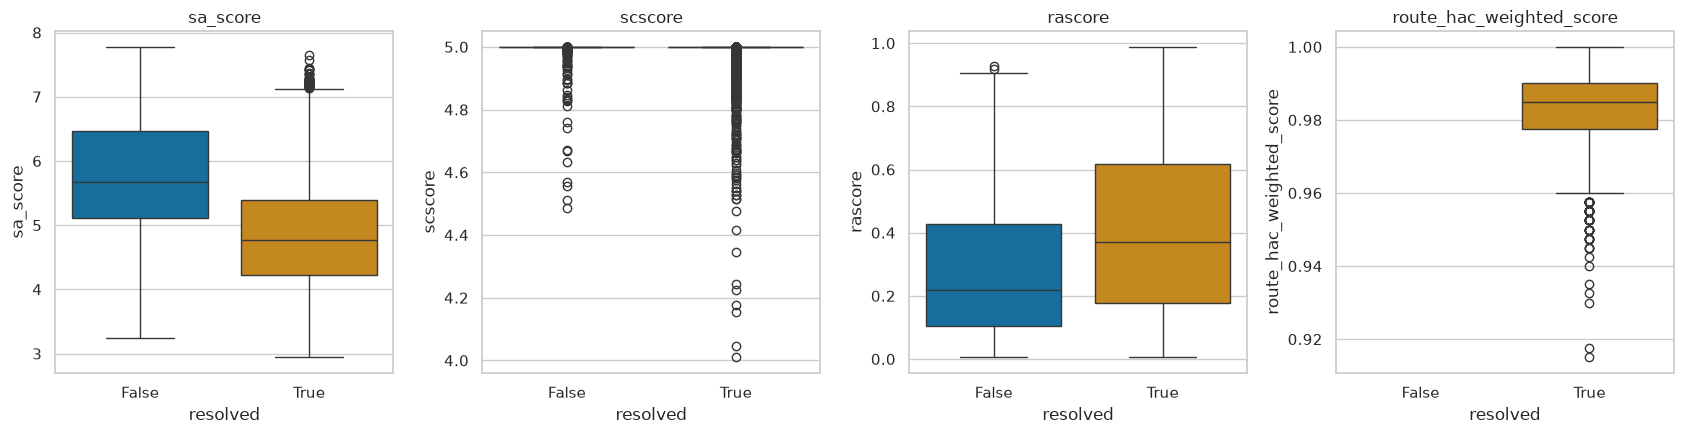

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.5))
for ax, col in zip(axes, ["sa_score", "scscore", "rascore", "route_hac_weighted_score"]):
    sns.boxplot(data=df, x="resolved", y=col, hue="resolved", palette=PALETTE[:2], legend=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()

## 4. Disagreement outliers

The most informative rows are where a cheap score and the LLM judge
*disagree* -- eyeball what's actually going on for those. `disagreement =
cheap_hardness_percentile - llm_hardness_percentile`: positive means the
cheap score thinks it's harder than the LLM judge does; negative means the
cheap score thinks it's easier (the riskier case for a triage workflow, since
it would wrongly deprioritize LLM review of something that's actually hard).

sa_score says EASIER than the LLM judge:


,SMILES,sa_score,llm_score,llm_category,disagreement
745,CC(=O)c1c(C)c2cnc(Nc3ccc(N4CCN(CC(=O)NCCOCCOCCC(=O)Nc5cc...,3.693006,38.333333,Route feasible with significant modifications,-92.1750
2315,NC(=O)c1c(-c2ccc(Oc3ccccc3)nc2)nn2c1Nc1ccc(N3CCN(CC4CCN(...,3.498616,41.666667,Route feasible with significant modifications,-92.1625
2514,NC(=O)c1c(-c2ccc(Oc3ccccc3)cc2)nn2c1Nc1ccc(CCC3CCN(c4ccc...,3.714301,41.666667,Route feasible with significant modifications,-89.0375
2541,COc1ccccc1C(=O)NCc1cc(F)c(-c2nn3c(c2C(N)=O)Nc2ccc(N4CCN(...,3.743507,41.666667,Challenging but feasible (multi-step / sensitive chemistry),-88.1125



sa_score says HARDER than the LLM judge:


,SMILES,sa_score,llm_score,llm_category,disagreement
2710,CCn1c(C)c(S(C)(=O)=O)c(-c2cc(F)cc(N3CCC4(CC3)CC(C(=O)NS(...,6.963109,88.666667,Route feasible as it is,89.3750
402,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC...,6.695019,90.000000,Route feasible as it is,87.8875
3420,CC1(C)CCC(CN2CCN3c4ccc(C(=O)NS(=O)(=O)c5ccc(N[C@H](CCN6C...,6.813345,88.333333,Route feasible as it is,86.3000
3866,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)nc(OCC5(CN6...,6.738721,88.333333,Route feasible as it is,85.0750


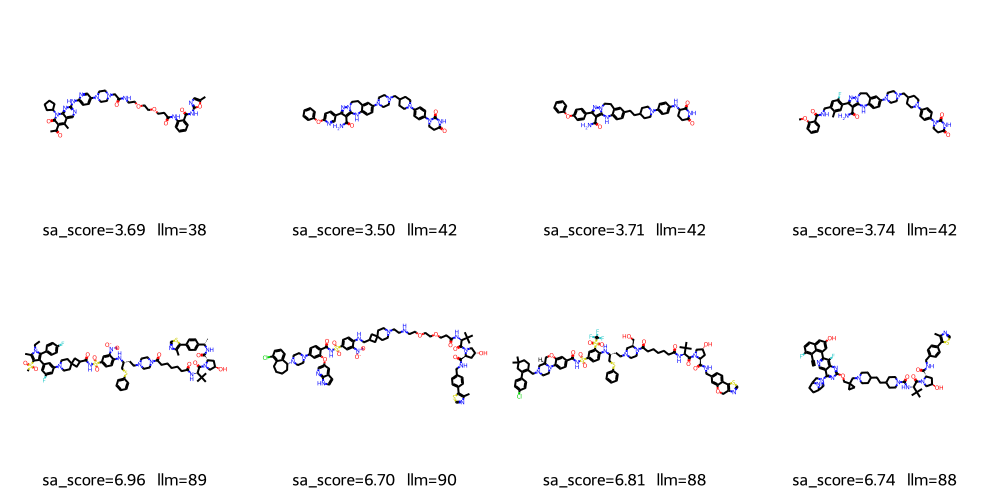

In [9]:
def show_disagreement(data, cheap_col, high_is_hard, n=4, mols_per_row=4):
    """Table + molecule grid for the N most extreme (cheap_col, llm_score) disagreements, both directions."""
    mask = data[cheap_col].notna() & data["llm_score"].notna()
    d = data.loc[mask].copy()
    d["cheap_hardness"] = hardness_percentile(d[cheap_col], high_is_hard)
    d["llm_hardness"] = hardness_percentile(d["llm_score"], high_is_hard=False)
    d["disagreement"] = d["cheap_hardness"] - d["llm_hardness"]

    cols = ["SMILES", cheap_col, "llm_score", "llm_category", "disagreement"]
    cheap_says_easier = d.nsmallest(n, "disagreement")
    cheap_says_harder = d.nlargest(n, "disagreement")

    print(f"{cheap_col} says EASIER than the LLM judge:")
    display(cheap_says_easier[cols])
    print(f"\n{cheap_col} says HARDER than the LLM judge:")
    display(cheap_says_harder[cols])

    combined = pd.concat([cheap_says_easier, cheap_says_harder])
    legends = [f"{cheap_col}={row[cheap_col]:.2f}  llm={row.llm_score:.0f}" for _, row in combined.iterrows()]
    return mol_grid(combined["SMILES"], legends, mols_per_row=mols_per_row)


show_disagreement(df, "sa_score", high_is_hard=True)

scscore says EASIER than the LLM judge:


,SMILES,scscore,llm_score,llm_category,disagreement
2285,Nc1nc2c(c(=O)[nH]1)[n+](Cc1ccccc1)cn2[C@@H]1O[C@H](COP(=...,4.741896,18.333333,Very challenging (long sequence / difficult selectivity ...,-98.4375
2554,Nc1nc2c(ncn2[C@@H]2O[C@H](COP(=O)(O)NCCCCCC(=O)Nc3cccc4c...,4.632110,31.666667,Very challenging (long sequence / difficult selectivity ...,-97.3000
1166,COc1cc(O[C@H]2C(C)(C)[C@H](NC(=O)c3ccc(N4CCN(C5Cc6ccc7c(...,4.623528,35.000000,Route feasible with significant modifications,-96.4375
2900,Nc1nc2c(c(=O)[nH]1)[n+](Cc1ccc(F)cc1)cn2[C@@H]1O[C@H](CO...,4.897110,18.333333,Very challenging (long sequence / difficult selectivity ...,-95.7125



scscore says HARDER than the LLM judge:


,SMILES,scscore,llm_score,llm_category,disagreement
328,CNC(C)C(=O)NC(C(=O)N1CCCC1c1nc(C(=O)c2cccc(OCCOCCOCCNC(=...,5.0,100.000000,Readily synthesizable (standard building blocks & coupli...,98.7375
1630,CCCS(=O)(=O)Nc1ccc(F)c(-n2cc(-c3cncnc3)c3nc(N(C)C4CCN(C(...,5.0,93.333333,Route feasible as it is,97.7500
221,Cn1c(=O)c2c(nc(N3CCN(C(=O)CCCCCCCNc4cccc5c4C(=O)N(C4CCC(...,5.0,91.666667,Route feasible as it is,96.1500
754,CN[C@@H](C)C(=O)N[C@H](C(=O)N1CCC[C@H]1c1nc(C(=O)c2cccc(...,5.0,100.000000,Readily synthesizable (standard building blocks & coupli...,95.6375


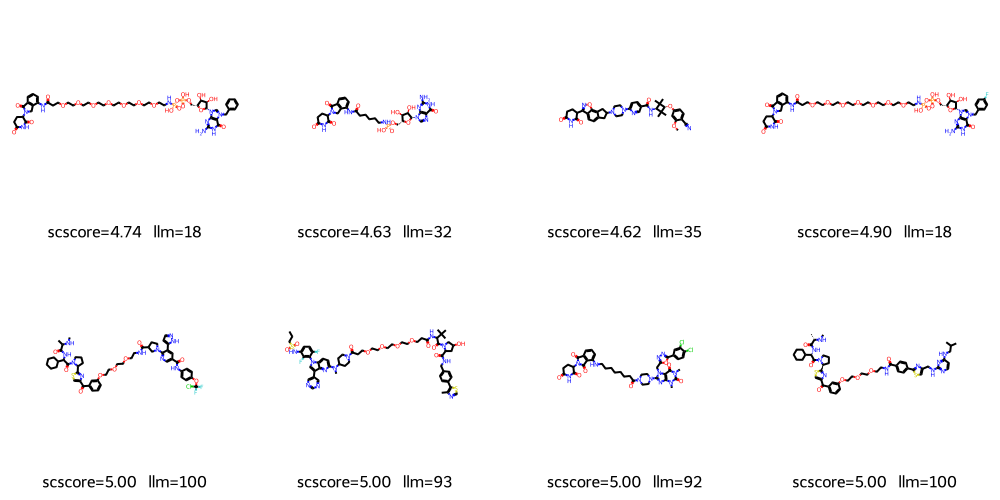

In [10]:
show_disagreement(df, "scscore", high_is_hard=True)

rascore says EASIER than the LLM judge:


,SMILES,rascore,llm_score,llm_category,disagreement
2104,O=C1CCC(N2Cc3cc(C4CCN(CC5(O)CCN(c6ccc(-c7cnc8[nH]cc(C(=O...,0.916911,33.333333,Very challenging (long sequence / difficult selectivity ...,-95.6875
3069,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)nc(OC[C@@]5...,0.803618,28.333333,Very challenging (long sequence / difficult selectivity ...,-90.1500
2583,Cc1ccc(C2=C(c3ccc(N4CCC(CN5CCN(c6ccc7c(c6)CN([C@H]6CCC(=...,0.902113,43.333333,Route feasible with significant modifications,-88.6125
2315,NC(=O)c1c(-c2ccc(Oc3ccccc3)nc2)nn2c1Nc1ccc(N3CCN(CC4CCN(...,0.858831,41.666667,Route feasible with significant modifications,-88.5875



rascore says HARDER than the LLM judge:


,SMILES,rascore,llm_score,llm_category,disagreement
3065,NC(=O)CC[C@H](NC(=O)[C@@H]1CC[C@@H]2CCN(C(=O)CCCCCC#Cc3c...,0.042378,100.0,Readily synthesizable (standard building blocks & coupli...,95.1250
977,Cc1cc(C(C(=O)N2CC(O)CC2C(=O)NC(CC(=O)N2CCC(N3CC(c4ccc(C(...,0.016703,90.0,Route feasible as it is,94.4375
754,CN[C@@H](C)C(=O)N[C@H](C(=O)N1CCC[C@H]1c1nc(C(=O)c2cccc(...,0.053812,100.0,Readily synthesizable (standard building blocks & coupli...,93.2250
3255,Cn1c(=O)n(C2CCC(=O)NC2=O)c2ccc(N3CCN(C(=O)Nc4cccc(CS(=O)...,0.032112,90.0,Route feasible as it is,92.6875


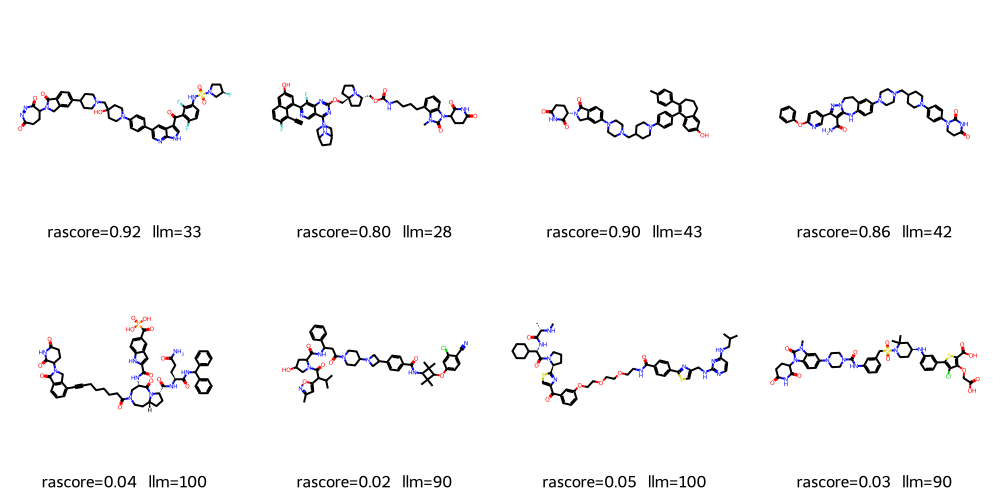

In [11]:
show_disagreement(df, "rascore", high_is_hard=False)

## 5. `llm_category` vs. continuous scores

`llm_category` is not one ordinal scale: the LLM judge uses a *route*
rubric (`llm_mode == "route"`) when a route was found and a different
*molecule* rubric (`llm_mode == "molecule_only"`) when it wasn't (plus a
trivial `"in_stock"` mode for targets that are themselves purchasable).
Mixing the two vocabularies into one ordering would be misleading, so they're
plotted separately below.

In [12]:
print(df["llm_mode"].value_counts(dropna=False))
print()
for mode in ["route", "molecule_only"]:
    print(f"-- {mode} --")
    print(df.loc[df["llm_mode"] == mode, "llm_category"].value_counts())
    print()

llm_mode
route            3381
molecule_only     565
in_stock           54
Name: count, dtype: int64

-- route --
llm_category
Route feasible as it is                          1411
Route feasible with few modifications             980
Route feasible with significant modifications     975
Route unfeasible                                   15
Name: count, dtype: int64

-- molecule_only --
llm_category
Challenging but feasible (multi-step / sensitive chemistry)                  458
Very challenging (long sequence / difficult selectivity or stereocontrol)    104
Synthesizable with routine medicinal-chemistry effort                          3
Name: count, dtype: int64



/tmp/ipykernel_2378159/3304403417.py:13: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.boxplot(data=route_df, x="llm_category", y=col, order=present, hue="llm_category",
/tmp/ipykernel_2378159/3304403417.py:13: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.boxplot(data=route_df, x="llm_category", y=col, order=present, hue="llm_category",
/tmp/ipykernel_2378159/3304403417.py:13: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.boxplot(data=route_df, x="llm_category", y=col, order=present, hue="llm_category",


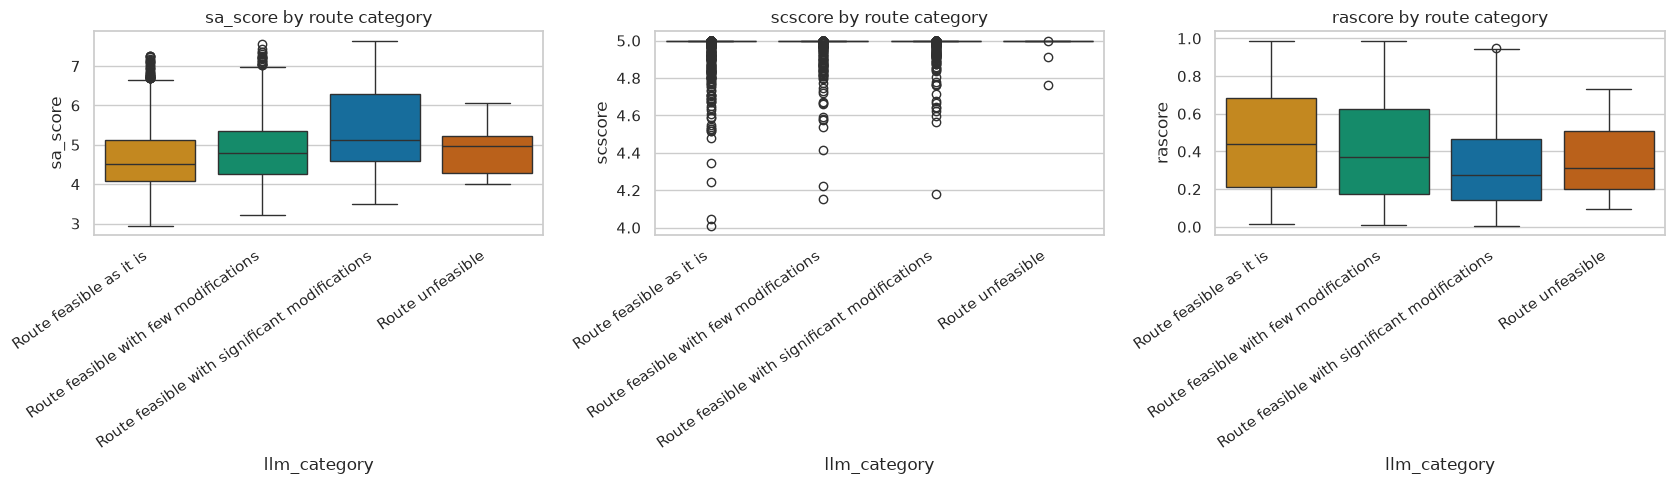

In [13]:
route_category_order = [
    "Route feasible as it is",
    "Route feasible with few modifications",
    "Route feasible with significant modifications",
    "Route unfeasible",
    "Route was not solved to building blocks",
]
route_df = df[df["llm_mode"] == "route"]
present = [c for c in route_category_order if c in route_df["llm_category"].unique()]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col in zip(axes, ["sa_score", "scscore", "rascore"]):
    sns.boxplot(data=route_df, x="llm_category", y=col, order=present, hue="llm_category",
               palette=PALETTE, legend=False, ax=ax)
    ax.set_xticks(range(len(present)))
    ax.set_xticklabels(present, rotation=35, ha="right")
    ax.set_title(f"{col} by route category")
plt.tight_layout()

/tmp/ipykernel_2378159/3785690769.py:13: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.boxplot(data=mol_df, x="llm_category", y=col, order=present, hue="llm_category",
/tmp/ipykernel_2378159/3785690769.py:13: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.boxplot(data=mol_df, x="llm_category", y=col, order=present, hue="llm_category",
/tmp/ipykernel_2378159/3785690769.py:13: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.boxplot(data=mol_df, x="llm_category", y=col, order=present, hue="llm_category",


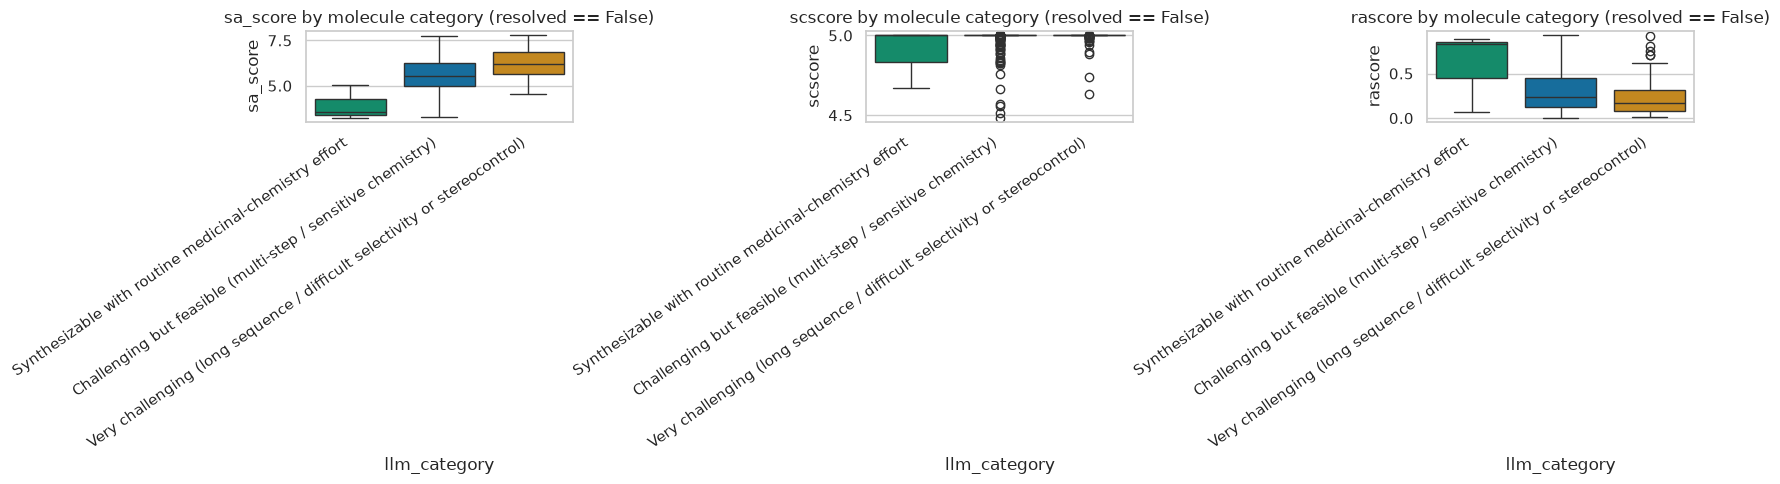

In [14]:
molecule_category_order = [
    "Readily synthesizable (standard building blocks & couplings)",
    "Synthesizable with routine medicinal-chemistry effort",
    "Challenging but feasible (multi-step / sensitive chemistry)",
    "Very challenging (long sequence / difficult selectivity or stereocontrol)",
    "Likely not synthesizable as drawn",
]
mol_df = df[df["llm_mode"] == "molecule_only"]
present = [c for c in molecule_category_order if c in mol_df["llm_category"].unique()]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col in zip(axes, ["sa_score", "scscore", "rascore"]):
    sns.boxplot(data=mol_df, x="llm_category", y=col, order=present, hue="llm_category",
               palette=PALETTE, legend=False, ax=ax)
    ax.set_xticks(range(len(present)))
    ax.set_xticklabels(present, rotation=35, ha="right")
    ax.set_title(f"{col} by molecule category (resolved == False)")
plt.tight_layout()

## 6. Route structure vs. score

Do longer or less convergent routes actually score worse, or is step count a
weak proxy? `route_convergence` is a cheap heuristic (building blocks per
step; >1 means branches merge, ~1 is mostly linear), not the literature
longest-linear-sequence metric -- see `scripts/chem_route_scoring/README.md`.

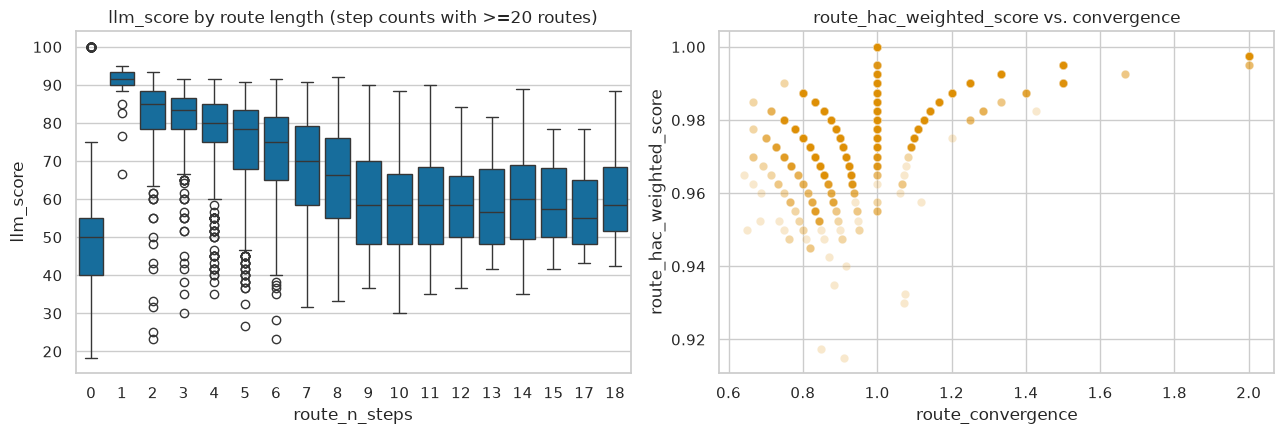

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

step_counts = df["route_n_steps"].value_counts()
common_steps = sorted(step_counts[step_counts >= 20].index)
sns.boxplot(data=df[df["route_n_steps"].isin(common_steps)], x="route_n_steps", y="llm_score",
           color=PALETTE[0], ax=axes[0])
axes[0].set_title("llm_score by route length (step counts with >=20 routes)")

sns.scatterplot(data=df, x="route_convergence", y="route_hac_weighted_score", alpha=0.2,
                color=PALETTE[1], ax=axes[1])
axes[1].set_title("route_hac_weighted_score vs. convergence")
plt.tight_layout()

## 7. AutoRank: are these scorers interchangeable?

Treat `sa_score`, `scscore`, `rascore`, `route_hac_weighted_score`, and
`llm_score` as five "methods" evaluated on the *same* set of resolved routes
(a block design, which is what `autorank` expects) by converting each to the
common `hardness_percentile` scale from the Helpers section. This asks a
sharper question than the pairwise correlations in Section 2: do these five
scorers produce **significantly different rank distributions** across the
dataset, or are some of them statistically interchangeable? Restricted to
resolved routes since `route_hac_weighted_score` is undefined otherwise
(autorank doesn't accept NaNs).

In [16]:
autorank_cols = ["sa_score", "scscore", "rascore", "route_hac_weighted_score", "llm_score"]
complete = df.dropna(subset=autorank_cols)

rank_df = pd.DataFrame({
    "SA_score":  hardness_percentile(complete["sa_score"], high_is_hard=True),
    "SCScore":   hardness_percentile(complete["scscore"], high_is_hard=True),
    "RAscore":   hardness_percentile(complete["rascore"], high_is_hard=False),
    "HAC_score": hardness_percentile(complete["route_hac_weighted_score"], high_is_hard=False),
    "LLM_score": hardness_percentile(complete["llm_score"], high_is_hard=False),
})
print(f"{len(rank_df)} routes with all five scores\n")

result = autorank(rank_df, alpha=0.05, order="descending")
create_report(result)
print(f"\nomnibus test significant at alpha={result.alpha}: {result.pvalue < result.alpha} (p={result.pvalue:.4f})")

3435 routes with all five scores

           meanrank     median        mad   ci_lower   ci_upper effect_size  \
LLM_score  3.039010  49.665211  24.032023   46.36099  53.682678         0.0   
RAscore    3.024891  50.014556  25.007278  46.928675  53.144105   -0.009608   
SCScore    3.016303  50.014556  25.007278  46.928675  53.158661   -0.009608   
HAC_score  2.982824  51.426492   24.96361  51.426492  51.426492   -0.048484   
SA_score   2.936972  50.029112  24.992722  46.928675  53.158661   -0.010011   

            magnitude effect_size_above magnitude_above  
LLM_score  negligible               0.0      negligible  
RAscore    negligible         -0.009608      negligible  
SCScore    negligible               0.0      negligible  
HAC_score  negligible         -0.038116      negligible  
SA_score   negligible          0.037734      negligible  
The statistical analysis was conducted for 5 populations with 3435 paired samples.
The family-wise significance level of the tests is alpha=0.0

/tmp/ipykernel_2378159/269841446.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


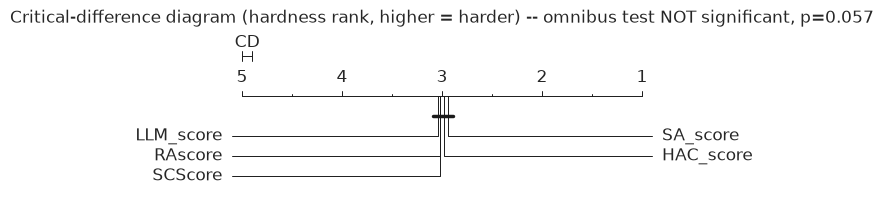

In [17]:
# allow_insignificant=True: plot_stats refuses to draw when the omnibus test
# isn't significant (it would otherwise imply differences the test didn't
# support), which happened when RAscore was added as a 5th population --
# force it anyway since the mean ranks are still descriptively informative,
# but the printed p-value above is the actual, honest answer to "are these
# scorers different", not this plot.
plot_stats(result, allow_insignificant=True)
significance = "SIGNIFICANT" if result.pvalue < result.alpha else "NOT significant"
plt.title(f"Critical-difference diagram (hardness rank, higher = harder) -- omnibus test {significance}, p={result.pvalue:.3f}")
plt.tight_layout()

## PROTAC / non-PROTAC classification QA

Separate from the synthesizability scoring above: `scripts/llm_scoring/classify_protac.py`'s
output, spot-checked here since a PROTAC-classification miss would quietly
bias any of the synthesizability analysis above if it were used as a filter.

In [18]:
protac_df = pd.read_csv("../data/llm_scoring/routes_with_classification_20260711135837.csv")
print(protac_df["llm_protac_label"].value_counts(dropna=False))

llm_protac_label
PROTAC        3914
non-PROTAC      76
NaN             10
Name: count, dtype: int64


76 molecules classified non-PROTAC (showing the 16 lowest-confidence)


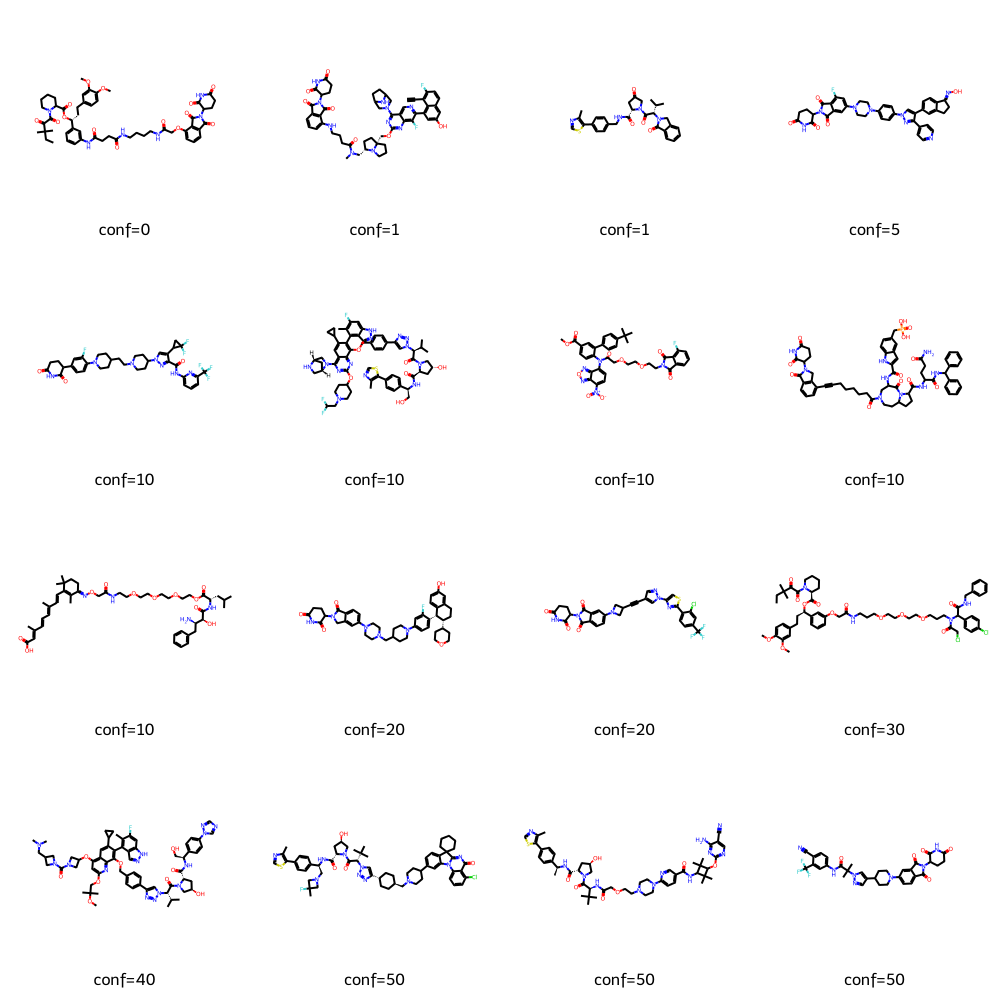

In [19]:
GRID_CAP = 16  # keep the inline grid readable; sort by confidence to see the most surprising misses first

non_protac = protac_df[protac_df["llm_protac_label"] == "non-PROTAC"].sort_values("llm_protac_confidence")
print(f"{len(non_protac)} molecules classified non-PROTAC (showing the {min(GRID_CAP, len(non_protac))} lowest-confidence)")
shown = non_protac.head(GRID_CAP)
legends = [f"conf={c:.0f}" for c in shown["llm_protac_confidence"]]
mol_grid(shown["SMILES"], legends, mols_per_row=4)

8 molecules classified PROTAC with <80 confidence (showing up to 16)


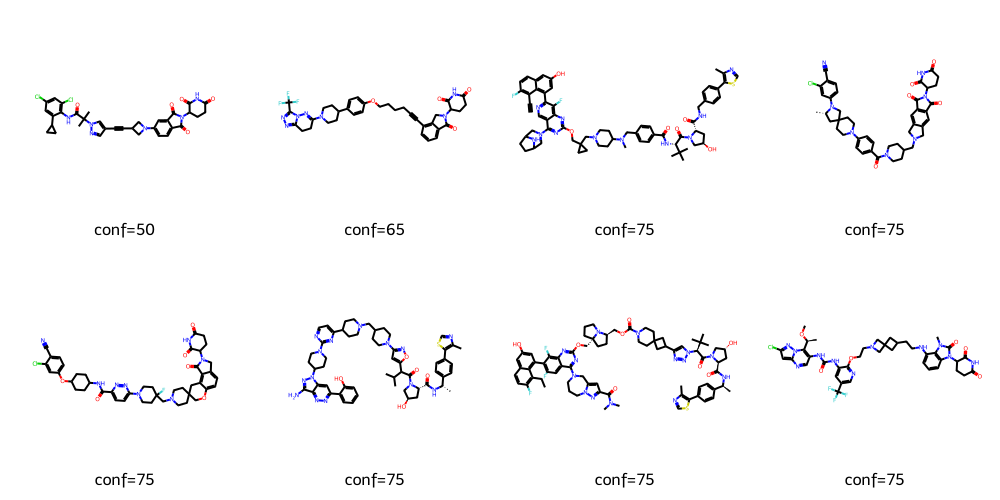

In [20]:
low_conf_protac = protac_df[(protac_df["llm_protac_label"] == "PROTAC") & (protac_df["llm_protac_confidence"] < 80)] \
    .sort_values("llm_protac_confidence")
print(f"{len(low_conf_protac)} molecules classified PROTAC with <80 confidence (showing up to {GRID_CAP})")
shown = low_conf_protac.head(GRID_CAP)
legends = [f"conf={c:.0f}" for c in shown["llm_protac_confidence"]]
mol_grid(shown["SMILES"], legends, mols_per_row=4)